<a href="https://colab.research.google.com/github/Julianajjss/tcc_dados_ips/blob/main/jsimao_ips_tcc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Imports
!pip install --quiet basedosdados

import basedosdados as bd
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# billing id
billing_id = "tcc-jornalismo-dados"

query = """
SELECT
  oportunidades_nota_dimensao,
  necessidades_humanas_basicas_nota_dimensao,
  moradia,
  liberdades_individuais,
  fundamentos_bem_estar_nota_dimensao,
  agua_saneamento,
  seguranca_pessoal,
  direitos_individuais,
  qualidade_meio_ambiente,
  tolerancia_inclusao,
  acesso_conhecimento_basico,
  ano,
  acesso_informacao,
  ips_geral,
  saude_bem_estar,
  regiao_administrativa,
  nutricao_cuidados_medicos_basicos,
  acesso_educacao_superior
FROM `basedosdados.br_rj_rio_de_janeiro_ipp_ips.dimensoes_componentes`
"""

conn = sqlite3.connect(":memory:")

# df
ips = bd.read_sql(query=query, billing_project_id=billing_id)

ips.to_sql("ips", conn, index=False, if_exists="replace")


Downloading: 100%|██████████|


99

Ranking de IPS

In [3]:
query = """
SELECT
  regiao_administrativa,
  AVG(ips_geral) as ips_medio
FROM ips
GROUP BY regiao_administrativa
ORDER BY ips_medio DESC
"""

ranking = pd.read_sql_query(query, conn)

ranking.head()

,regiao_administrativa,ips_medio
0,Botafogo,86.413333
1,Lagoa,83.273333
2,Copacabana,81.430000
3,Tijuca,75.516667
4,Vila Isabel,73.633333


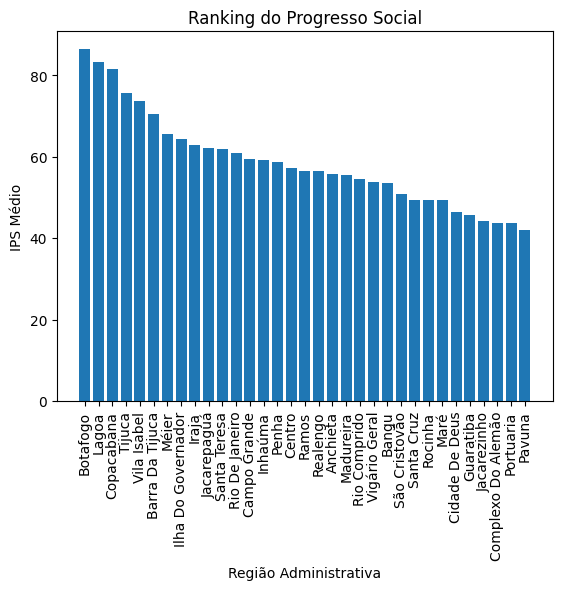

In [4]:
plt.figure()

plt.bar(ranking["regiao_administrativa"], ranking["ips_medio"])

plt.xticks(rotation=90)
plt.xlabel("Região Administrativa")
plt.ylabel("IPS Médio")
plt.title("Ranking do Progresso Social")

plt.show()

Relação segurança x IPS

In [7]:
query = """
SELECT
  ips_geral,
  seguranca_pessoal
FROM ips
"""

seguranca = pd.read_sql_query(query, conn)

seguranca.head()

,ips_geral,seguranca_pessoal
0,60.77,71.34
1,45.33,0.00
2,57.75,24.31
3,52.43,25.52
4,87.12,90.08


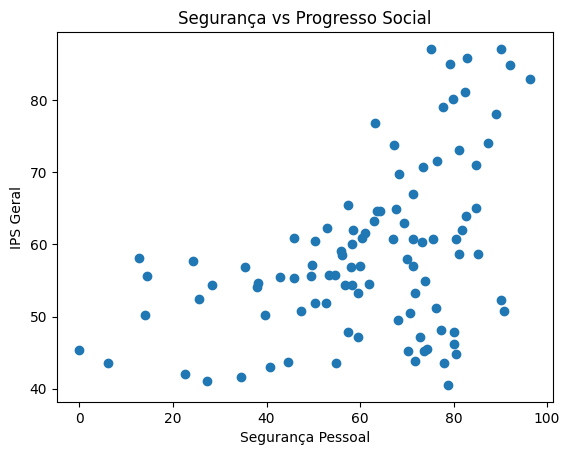

In [8]:
plt.figure()

plt.scatter(seguranca["seguranca_pessoal"], seguranca["ips_geral"])

plt.xlabel("Segurança Pessoal")
plt.ylabel("IPS Geral")
plt.title("Segurança vs Progresso Social")

plt.show()

Educação x Oportunidades

In [11]:
query = """
SELECT
  acesso_educacao_superior,
  oportunidades_nota_dimensao
FROM ips
"""

educacao = pd.read_sql_query(query, conn)

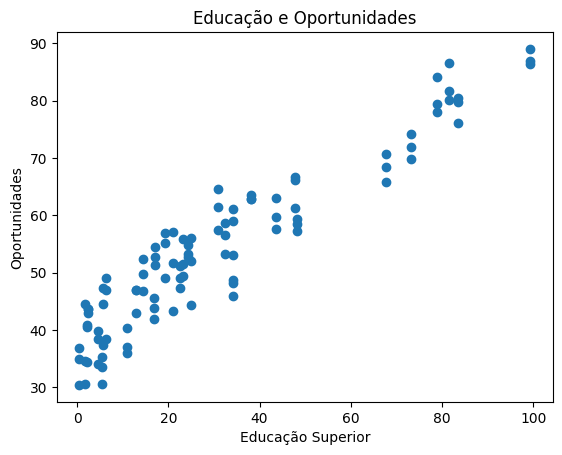

In [12]:
plt.figure()

plt.scatter(
    educacao["acesso_educacao_superior"],
    educacao["oportunidades_nota_dimensao"]
)

plt.xlabel("Educação Superior")
plt.ylabel("Oportunidades")
plt.title("Educação e Oportunidades")

plt.show()

Média IPS por região

In [13]:
query = """
SELECT
  regiao_administrativa,
  AVG(acesso_conhecimento_basico) as conhecimento,
  AVG(saude_bem_estar) as saude,
  AVG(nutricao_cuidados_medicos_basicos) as nutricao,
  AVG(acesso_informacao) as informacao
FROM ips
GROUP BY regiao_administrativa
ORDER BY conhecimento DESC
"""

df_indicadores = pd.read_sql_query(query, conn)

df_indicadores.head()

,regiao_administrativa,conhecimento,saude,nutricao,informacao
0,Botafogo,78.273333,81.666667,88.866667,86.52
1,Copacabana,73.733333,74.690000,85.940000,81.95
2,Santa Teresa,70.470000,62.636667,71.956667,59.89
3,Lagoa,68.100000,82.046667,75.753333,89.06
4,Barra Da Tijuca,64.633333,81.633333,80.140000,78.51


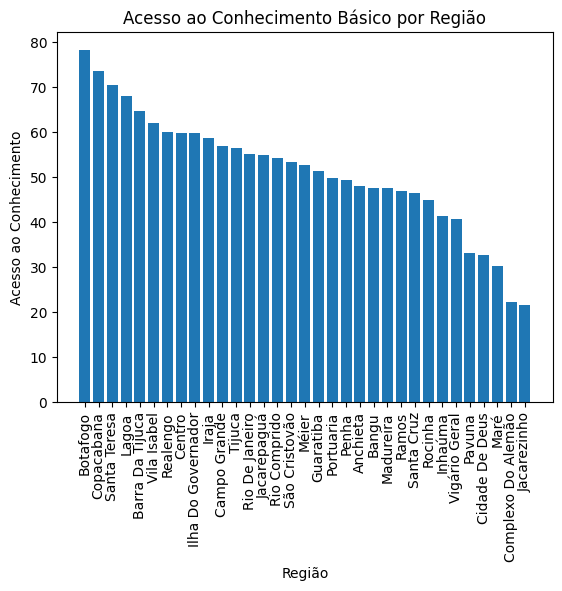

In [14]:
plt.figure()

plt.bar(df_indicadores["regiao_administrativa"], df_indicadores["conhecimento"])

plt.xticks(rotation=90)
plt.xlabel("Região")
plt.ylabel("Acesso ao Conhecimento")
plt.title("Acesso ao Conhecimento Básico por Região")

plt.show()

Comparação entre indicadores

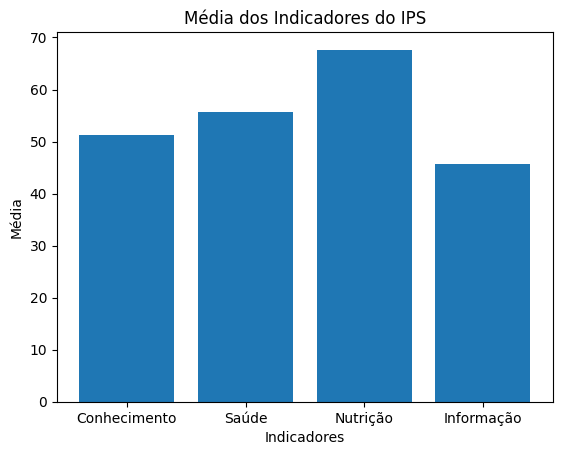

In [15]:
medias = [
    df_indicadores["conhecimento"].mean(),
    df_indicadores["saude"].mean(),
    df_indicadores["nutricao"].mean(),
    df_indicadores["informacao"].mean()
]

nomes = ["Conhecimento", "Saúde", "Nutrição", "Informação"]

plt.figure()

plt.bar(nomes, medias)

plt.xlabel("Indicadores")
plt.ylabel("Média")
plt.title("Média dos Indicadores do IPS")

plt.show()

In [17]:
query = """
SELECT
  regiao_administrativa,
  AVG(acesso_informacao) as info,
  AVG(acesso_conhecimento_basico) as conhecimento
FROM ips
GROUP BY regiao_administrativa
"""

df_plot = pd.read_sql_query(query, conn)

df_plot.head()

,regiao_administrativa,info,conhecimento
0,Anchieta,36.94,48.153333
1,Bangu,33.54,47.683333
2,Barra Da Tijuca,78.51,64.633333
3,Botafogo,86.52,78.273333
4,Campo Grande,40.10,56.890000


In [19]:
df_plot["info_pct"] = df_plot["info"] * 100
df_plot["conhecimento_pct"] = df_plot["conhecimento"] * 100

In [20]:
df_plot = df_plot.sort_values("info_pct")

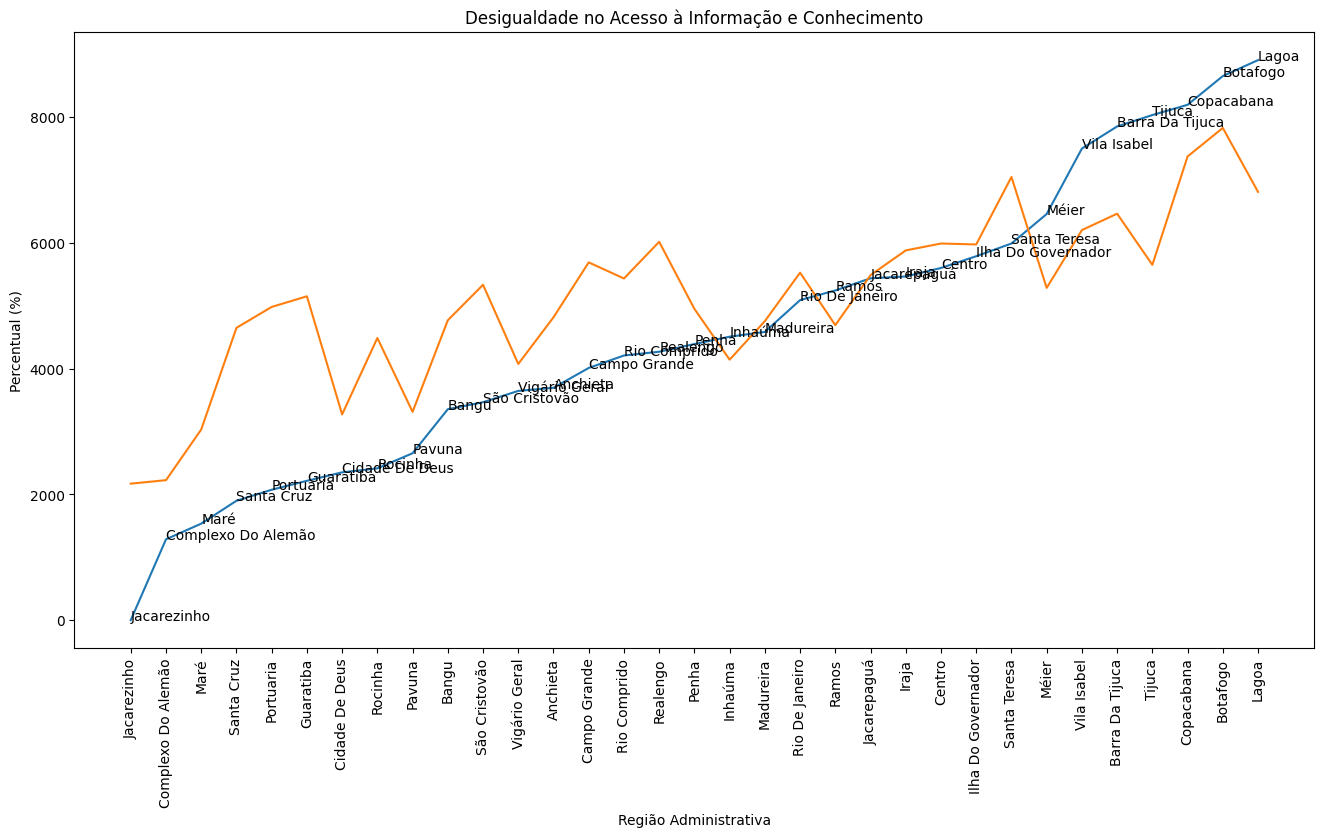

In [22]:
plt.figure(figsize=(16,8))  # largura, altura

plt.plot(df_plot["regiao_administrativa"], df_plot["info_pct"])
plt.plot(df_plot["regiao_administrativa"], df_plot["conhecimento_pct"])

for i, txt in enumerate(df_plot["regiao_administrativa"]):
    plt.annotate(
        txt,
        (df_plot["regiao_administrativa"].iloc[i], df_plot["info_pct"].iloc[i])
    )

plt.xticks(rotation=90)

plt.xlabel("Região Administrativa")
plt.ylabel("Percentual (%)")
plt.title("Desigualdade no Acesso à Informação e Conhecimento")

plt.show()